# PROJECT : Composer Identification from MIDI Scores using CNN-LSTM (CRNN)


This notebook builds a deep learning pipeline that identifies the composer
(Bach, Beethoven, Chopin, or Mozart) of a classical piano piece from its
MIDI score, using a hybrid **CNN + LSTM ("CRNN")** architecture.

**Dataset:** [MIDI Classic Music (Kaggle)](https://www.kaggle.com/datasets/blanderbuss/midi-classic-music),
filtered to the four target composers.

What are MIDI files ?
MIDI (Musical Instrument Digital Interface) (.mid or .midi) files are not audio recordings. Instead, they contain instructions or data about how music should be played. Think of it like a recipe for music. A MIDI file stores information such as:

Note On/Off: When a note starts and stops.
Pitch: Which note to play (e.g., C4, F#5).
Velocity: How hard or soft a note is played (corresponding to loudness).
Duration: How long a note is held.
Instrument: Which instrument sound should play the note.
Tempo: The speed of the music.
Controller Information: Data for things like sustain pedals, pitch bends, and other musical expressions.


**Pipeline overview**
1. Data Collection
2. Data Pre-processing
3. Feature Extraction
4. Model Building (CNN + LSTM hybrid)
5. Model Training
6. Model Evaluation
7. Model Optimization / Hyperparameter Tuning discussion


## 0. Setup

In [132]:
# !pip install pretty_midi

In [133]:
import kagglehub

import os
import time
import warnings
import json

import numpy as np
import matplotlib.pyplot as plt
import pretty_midi
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

warnings.filterwarnings('ignore')


# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [134]:
import os

path = "/kaggle/input/midi-classic-music/"
print(f"Dataset path: {path}")

Dataset path: /kaggle/input/midi-classic-music/


In [135]:
print(os.listdir(path + "/midiclassics/"))

['Pachebel Toccata n1.mid', 'Alkan', 'Lyssenko', 'Brahms', 'Couperin', 'Liszt Paganini Etude n5.mid', 'Chasins', 'Friedman', 'Meyerbeer', 'Dvorak', 'Debussy', "Liszt Ab irato ''The Perfect Etude'' S143 R4b.mid", 'Botsford', 'Wolf', 'Hummel', 'Buxehude', 'MacCunn', 'Lange', 'Rothchild Horn Concerto Rmw16 2mov.mid', 'Moszkowski', 'Bizet Symphony in C 4mov.mid', 'Gershuin Rhapsody In Blue Piano Duet.mid', 'Reger Burlesque op58 n6.mid', 'Lecuona', 'Morel', 'Arensky', 'Griffes', 'Clarke', 'Debussy Suite Bergamasque 1mov.mid', 'Bartok', 'Rothchild Piano Sonata Rmw13 1mov.mid', 'Bizet Symphony in C 3mov.mid', 'Hemery', "Rimsky Korsakov ''Flight Of the Bumblebee''.mid", 'Prokofiev', 'Diabelli Sonatina op151 n1 3mov.mid', 'Liszt Paganini Etude n1.mid', 'Flotow', 'Buxethude Buxwv162 Prelude.mid', 'Frescobaldi', 'Kuhlau Sonatina op20 n1.mid', 'Faure', 'Dvorak Symphony op70 n7 1mov.mid', 'Maier', 'Tchakoff', 'Becker', 'Verdi', 'Pachelbel', 'Bizet Symphony in C 1mov.mid', "Albe'niz", 'Chabrier', 'B

In [136]:
COMPOSERS = ['Bach', 'Beethoven', 'Chopin', 'Mozart']

## 1. Data Collection

The Kaggle dataset contains MIDI files organized by composer . We retained only the four target composers ['Bach', 'Beethoven', 'Chopin', 'Mozart'] and recursively scanned the folders to create a file catalog.

In [137]:
DATA_PATH = path + "/midiclassics/"

def build_catalog(data_dir, composers):
    catalog = []
    for c in composers:
        for root, _, files in os.walk(os.path.join(data_dir, c)):
            for fn in files:
                if fn.lower().endswith(('.mid', '.midi')):
                    # print(fn)
                    catalog.append((os.path.join(root, fn), c))
    return catalog

catalog = build_catalog(DATA_PATH, COMPOSERS)
print(f"Total MIDI files found: {len(catalog)}")
for c in COMPOSERS:
    n = sum(1 for _, comp in catalog if comp == c)
    print(f"  {c}: {n} files")

Total MIDI files found: 1630
  Bach: 1024 files
  Beethoven: 213 files
  Chopin: 136 files
  Mozart: 257 files


NOTE: COMPOSER **Bach** alone accounts for nearly two-thirds
of all files ie 1024 files. We need to address the class weight during the training.

## 2. Data Pre-processing

Each MIDI file is parsed with `pretty_midi`, which merges all instrument
tracks into a single **piano-roll** representation: a 2-D matrix of
shape `(pitch, time)` where each cell indicates whether a given MIDI
pitch (0-127) is sounding at a given time frame. We:

- Restrict to the 88-key piano pitch range (21-108) to drop percussion /
  extreme registers that add noise without musical information.
- Binarize the roll (note on/off) for robustness across files with very
  different velocity/dynamics encodings.
- Filter out files with degenerate duration (parsing artifacts can
  occasionally produce durations of 0 or several hours from malformed
  tempo-change events).

In [138]:
FS = 10                           # piano-roll sampling rate (frames / second)
PITCH_LOW, PITCH_HIGH = 21, 109   # standard 88-key piano range [21, 108]
MIN_DURATION = 8            # skip pieces shorter than this (seconds)
MAX_DURATION = 1800         # skip malformed files with absurd duration

###  Parse a MIDI file into a binarized, pitch-restricted piano roll
def load_piano_roll(filepath):
    pm = pretty_midi.PrettyMIDI(filepath)
    duration = pm.get_end_time()
    if duration < MIN_DURATION or duration > MAX_DURATION:
        return None
    roll = pm.get_piano_roll(fs=FS)                      # (128, T)
    roll = roll[PITCH_LOW:PITCH_HIGH, :]                 # (88, T)
    roll = (roll > 0).astype(np.float32)                 # binarize
    return roll

### Sample test on one file
sample_path, sample_composer = catalog[1500]
roll = load_piano_roll(sample_path)
print(f"Sample: {os.path.basename(sample_path)} ({sample_composer})")
print("Piano-roll shape (pitch x time):", None if roll is None else roll.shape)

Sample: Symphony n34 K338 1mov.mid (Mozart)
Piano-roll shape (pitch x time): (88, 4260)


## 3. Feature Extraction

Full pieces vary from ~18 seconds to nearly 90 minutes, which is far too
variable to feed directly into a fixed-size network. We slide a
**4-second window** (with 2-second hop, i.e. 50% overlap) across each
piece's piano roll, extracting up to `MAX_WINDOWS_PER_PIECE` windows per
piece. This:

- Produces a fixed-size input tensor per sample: `(88 pitches, 40 time
  frames, 1 channel)`.
- Acts as a form of data augmentation — Each piece contributes several
  (mildly correlated) training examples drawn from different sections.
- Keeps the dataset size manageable while still covering each piece's
  musical content reasonably well.

Each window keeps a `piece_id` tag so that, later, we can split
train/validation/test **by piece** rather than by window — this prevents
data leakage (windows from the same piece appearing in both train and
test).

In [139]:
FS = 10                     ### piano-roll sampling rate (frames / second)
WINDOW_SEC = 4              ### length of each training window, in seconds
HOP_SEC = 2                 ### hop between successive windows (50% overlap)
MAX_WINDOWS_PER_PIECE = 8   ### cap per piece so long pieces don't dominate

WINDOW_FRAMES = WINDOW_SEC * FS
HOP_FRAMES = HOP_SEC * FS

def extract_windows(roll):    ### Extract Window frames from the roll.
    T = roll.shape[1]
    windows = []
    start = 0
    while start + WINDOW_FRAMES <= T and len(windows) < MAX_WINDOWS_PER_PIECE:
        windows.append(roll[:, start:start + WINDOW_FRAMES])
        start += HOP_FRAMES
    if not windows and T >= WINDOW_FRAMES // 2:
        pad = np.zeros((roll.shape[0], WINDOW_FRAMES), dtype=np.float32)
        pad[:, :min(T, WINDOW_FRAMES)] = roll[:, :WINDOW_FRAMES] if T >= WINDOW_FRAMES else roll
        windows.append(pad)
    return windows


def build_dataset(catalog):
    X, y, piece_ids = [], [], []
    t0 = time.time()
    n_failed = 0
    for i, (fp, composer) in enumerate(catalog):
        try:
            roll = load_piano_roll(fp)             ### Load each piano roll
            if roll is None:
                n_failed += 1
                continue
            for w in extract_windows(roll):        ### Extract Window frames from the roll.
                X.append(w)
                y.append(composer)
                piece_ids.append(i)
        except Exception:
            n_failed += 1
            continue
    X = np.stack(X).astype(np.float32)[..., np.newaxis]   # (N, 88, 40, 1) - Window shape
    y = np.array(y)
    piece_ids = np.array(piece_ids)
    print(f"Feature extraction done in {time.time()-t0:.1f}s. Skipped {n_failed} files.")
    return X, y, piece_ids

# This takes ~90 seconds over the full 1630-file corpus.
X, y_raw, piece_ids = build_dataset(catalog)
print(f"Total windows: {X.shape[0]}, window shape: {X.shape[1:]}")
for c in COMPOSERS:
    print(f"  {c}: {int(np.sum(y_raw == c))} windows")

Feature extraction done in 142.7s. Skipped 5 files.
Total windows: 12999, window shape: (88, 40, 1)
  Bach: 8183 windows
  Beethoven: 1680 windows
  Chopin: 1088 windows
  Mozart: 2048 windows


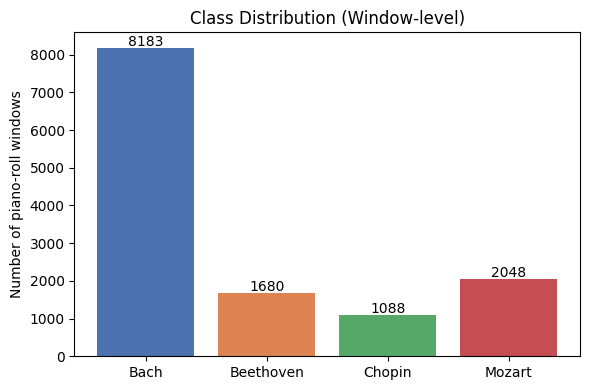

In [140]:
fig, ax = plt.subplots(figsize=(6,4))
counts = [int(np.sum(y_raw == c)) for c in COMPOSERS]
ax.bar(COMPOSERS, counts, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
ax.set_ylabel('Number of piano-roll windows')
ax.set_title('Class Distribution (Window-level)')
for i, v in enumerate(counts):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.show()

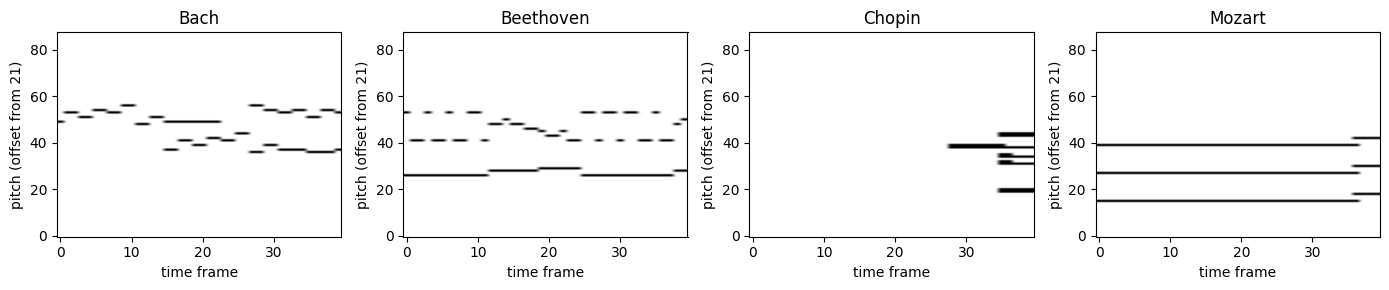

In [141]:
# Visualize one example window per composer
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, c in zip(axes, COMPOSERS):
    idx = np.where(y_raw == c)[0][0]
    ax.imshow(X[idx, :, :, 0], aspect='auto', origin='lower', cmap='Greys')
    ax.set_title(c)
    ax.set_xlabel('time frame')
    ax.set_ylabel('pitch (offset from 21)')
plt.tight_layout()
plt.show()

## 4. Train / Validation / Test Split

We use a **grouped split** keyed on `piece_id`: all windows from a given
piece go entirely into train, validation, or test — never split across
sets. This avoids an easy but misleading form of leakage (the model
"memorizing" a specific piece's timbral fingerprint rather than learning
composer style). Split ratios: 70% train / 15% val / 15% test.

In [163]:
le = LabelEncoder()
y = le.fit_transform(y_raw)
classes = le.classes_
print("Classes:", list(classes))

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss1.split(X, y, groups=piece_ids))

X_temp, y_temp, groups_temp = X[temp_idx], y[temp_idx], piece_ids[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx_rel, test_idx_rel = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X_temp[val_idx_rel], y_temp[val_idx_rel]
X_test, y_test = X_temp[test_idx_rel], y_temp[test_idx_rel]

print(f"Train: {X_train.shape[0]}  Val: {X_val.shape[0]}  Test: {X_test.shape[0]}")

# Confirm no piece-level leakage
train_pieces = set(piece_ids[train_idx])
val_pieces = set(groups_temp[val_idx_rel])
test_pieces = set(groups_temp[test_idx_rel])
assert not (train_pieces & val_pieces)
assert not (train_pieces & test_pieces)
assert not (val_pieces & test_pieces)
print("No piece-level leakage between splits: confirmed")

for name, yy in [('train', y_train), ('val', y_val), ('test', y_test)]:
    dist = {classes[c]: int(np.sum(yy == c)) for c in range(len(classes))}
    print(name, dist)

Classes: [np.str_('Bach'), np.str_('Beethoven'), np.str_('Chopin'), np.str_('Mozart')]
Train: 9096  Val: 1952  Test: 1951
No piece-level leakage between splits: confirmed
train {np.str_('Bach'): 5664, np.str_('Beethoven'): 1208, np.str_('Chopin'): 760, np.str_('Mozart'): 1464}
val {np.str_('Bach'): 1288, np.str_('Beethoven'): 280, np.str_('Chopin'): 144, np.str_('Mozart'): 240}
test {np.str_('Bach'): 1231, np.str_('Beethoven'): 192, np.str_('Chopin'): 184, np.str_('Mozart'): 344}


In [164]:
# Class weights to counter Bach's dominance in the training loss
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {i: w for i, w in enumerate(class_weights_arr)}
print("Class weights:", {classes[i]: round(w, 2) for i, w in class_weight.items()})

Class weights: {np.str_('Bach'): np.float64(0.4), np.str_('Beethoven'): np.float64(1.88), np.str_('Chopin'): np.float64(2.99), np.str_('Mozart'): np.float64(1.55)}


## 5. Model Building — Hybrid CNN-LSTM (CRNN)

The architecture combines both techniques required by the brief:

- **CNN front-end** (2× Conv2D + BatchNorm + MaxPool + Dropout) treats
  each piano-roll window as an image and learns local pitch/time
  patterns — e.g. chord shapes, characteristic intervals, texture
  density — the kind of "vertical" and short-range "horizontal"
  structure that distinguishes, say, Bach's dense counterpoint from
  Chopin's arpeggiated, sparser textures.
- The CNN's output feature maps are **reshaped into a sequence**
  (time steps × flattened pitch-channel features).
- **LSTM back-end** (2 stacked LSTM layers) models longer-range temporal
  structure across that sequence — melodic contour, rhythmic patterns,
  phrase-level structure.
- A small **dense classifier head** with softmax produces the final
  4-way composer probability distribution.

In [165]:
n_classes = len(classes)
input_shape = X_train.shape[1:]   # (88, 40, 1)

inputs = layers.Input(shape=input_shape, name='piano_roll')

# --- CNN feature extractor ---
x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# --- reshape (pitch, time, channels) -> (time, pitch*channels) for LSTM ---
shape = x.shape
x = layers.Permute((2, 1, 3))(x)                        # (time, pitch, channels)
x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)   # (time, pitch*channels)

# --- LSTM temporal modeling ---
x = layers.LSTM(128, return_sequences=True)(x)
x = layers.Dropout(0.3)(x)
x = layers.LSTM(64)(x)
x = layers.Dropout(0.3)(x)

# --- classifier head ---
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(n_classes, activation='softmax')(x)

model = models.Model(inputs, outputs, name='CRNN_composer_id')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "CRNN_composer_id"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ piano_roll (InputLayer)         │ (None, 88, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 88, 40, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 88, 40, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 44, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 44, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 44, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 44, 20, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 22, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute_3 (Permute)             │ (None, 10, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 10, 1408)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 10, 128)        │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 859,972 (3.28 MB)

 Trainable params: 859,780 (3.28 MB)

 Non-trainable params: 192 (768.00 B)

## 6. Model Training

We train with early stopping (patience 5 on validation loss) and a
learning-rate reduction on plateau, both standard, effective defaults
for this size of dataset/model. `class_weight` is passed to compensate
for Bach's over-representation. Training ran for 15 epochs before early
stopping triggered (best weights restored from epoch 10).

In [166]:
cb = [
   tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
   tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
]

# cb = [
#     tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, mode="min", restore_best_weights=True),
#     tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_loss", mode="min", save_best_only=True)
# ]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=64,
    class_weight=class_weight,
    callbacks=cb,
    verbose=2,
)

Epoch 1/30
143/143 - 5s - 38ms/step - accuracy: 0.4814 - loss: 1.2677 - val_accuracy: 0.3755 - val_loss: 1.2522 - learning_rate: 0.0010
Epoch 2/30
143/143 - 2s - 11ms/step - accuracy: 0.5886 - loss: 1.0629 - val_accuracy: 0.2387 - val_loss: 1.3144 - learning_rate: 0.0010
Epoch 3/30
143/143 - 2s - 11ms/step - accuracy: 0.6551 - loss: 0.8871 - val_accuracy: 0.4052 - val_loss: 1.3139 - learning_rate: 0.0010
Epoch 4/30
143/143 - 2s - 11ms/step - accuracy: 0.7073 - loss: 0.7405 - val_accuracy: 0.6588 - val_loss: 0.8659 - learning_rate: 0.0010
Epoch 5/30
143/143 - 2s - 12ms/step - accuracy: 0.7457 - loss: 0.6398 - val_accuracy: 0.6450 - val_loss: 0.9653 - learning_rate: 0.0010
Epoch 6/30
143/143 - 2s - 12ms/step - accuracy: 0.7836 - loss: 0.5422 - val_accuracy: 0.7613 - val_loss: 0.6899 - learning_rate: 0.0010
Epoch 7/30
143/143 - 2s - 11ms/step - accuracy: 0.8170 - loss: 0.4345 - val_accuracy: 0.6276 - val_loss: 1.1494 - learning_rate: 0.0010
Epoch 8/30
143/143 - 2s - 11ms/step - accuracy: 

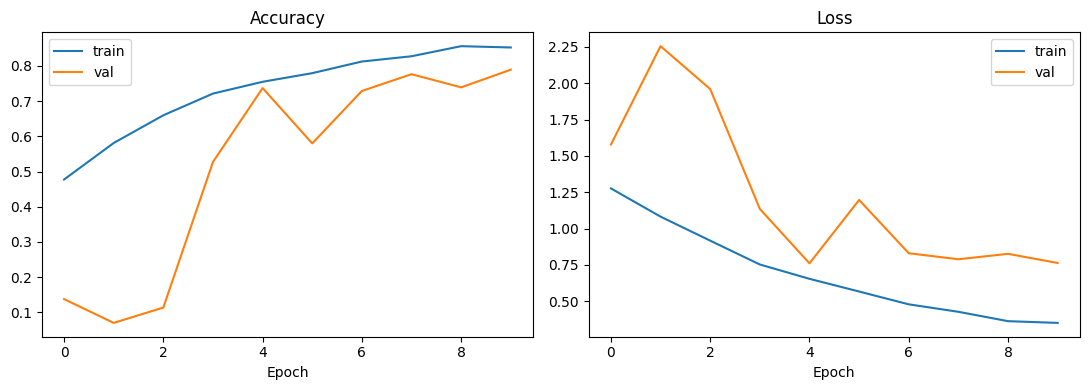

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout()
plt.show()

- Training accuracy steadily rises from 48% to 90%.
- Validation accuracy rises to about 72% by epoch 5, then fluctuates between 56–77%.
- Training loss consistently declines from 1.27 to 0.22.
- Validation loss reaches its lowest region around epochs 5–7 (~0.78), then becomes unstable and generally higher.

## 7. Model Evaluation

Evaluated on the held-out **test set** (windows from pieces never seen
during training or validation).

In [167]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")

y_pred_probs = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

print()
print(classification_report(y_test, y_pred, target_names=classes, digits=3))

Test accuracy: 0.7529
Test loss: 0.7325

              precision    recall  f1-score   support

        Bach      0.891     0.847     0.868      1231
   Beethoven      0.468     0.458     0.463       192
      Chopin      0.624     0.560     0.590       184
      Mozart      0.550     0.683     0.610       344

    accuracy                          0.753      1951
   macro avg      0.633     0.637     0.633      1951
weighted avg      0.764     0.753     0.757      1951



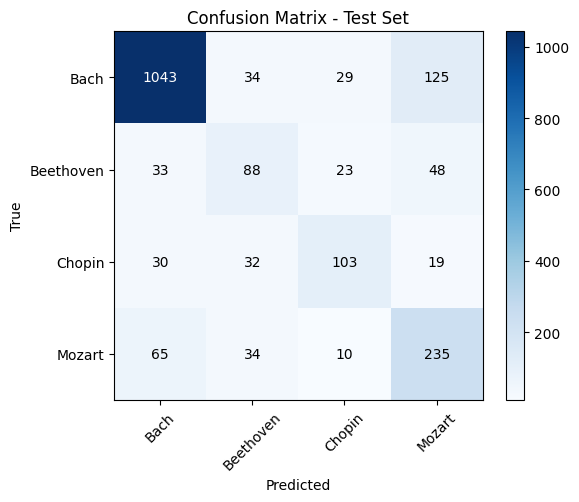

In [168]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Test Set')
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

**Results summary**

- Overall test accuracy: 75.3% — 1,469 correct predictions out of 1,951 samples. This exceeds the random baseline (25%) and majority-class baseline (63.1%).
- Bach performs best: precision 89.1%, recall 84.7%, and F1 86.8%. Its most common misclassification is Mozart (125 cases).
- Beethoven performs worst: precision 46.8%, recall 45.8%, and F1 46.3%. It is most often misclassified as Mozart (48 cases), followed by Bach (33) and Chopin (23).
- Chopin: precision 62.4%, recall 56.0%, and F1 59.0%. Its largest confusion is with Beethoven (32 cases).
- Mozart: precision 55.0%, recall 68.3%, and F1 61.0%. It is most often misclassified as Bach (65 cases).
- Macro-average F1: 63.3%, showing weaker performance when all composers receive equal importance.
Weighted-average F1: 75.7%, influenced strongly by the much larger Bach class.

## 8. Model Optimization / Hyperparameter Tuning

The model already uses several methods to improve generalization:

- Dropout to reduce overfitting.
- Batch normalization to stabilize training.
- Class weights to address the class imbalance.
- Early stopping to stop training when validation loss no longer improves.
- Learning-rate reduction to make smaller updates when learning slows down.

Further lets use kesar tuner with more computing time.
| Hyperparameter | Values to try | Rationale |
|---|---|---|
| Window length | 2s, 4s, 8s | Longer windows give the LSTM more context per sample but fewer, less varied samples per piece |
| CNN filters | 16/32, 32/64, 64/128 | More filters may capture finer chordal/textural detail, at higher overfitting risk |
| LSTM units | 64/32, 128/64, 256/128 | Larger LSTMs model longer dependencies but need more data / stronger regularization |
| Learning rate | 1e-4, 5e-4, 1e-3 | Lower LR + more epochs may reach a better minimum, at higher training cost |
| Windows per piece | 4, 8, 16 | More windows per piece increases dataset size but also intra-piece correlation between train examples |
| Imbalance strategy | class weights (used), oversampling minority classes, undersampling Bach | Class weights are the least destructive to available data, but oversampling could push minority recall higher |
| Input representation | binarized (used), velocity-weighted, onset-only | Velocity information may help distinguish Beethoven's dynamic contrasts specifically |

Given Beethoven/Mozart confusion is the main weakness, a promising next
step is adding an auxiliary feature (e.g. **note density, average
polyphony, or tempo-change statistics**) as a side input concatenated
before the final dense layer, since these hand-crafted features can
capture stylistic cues that a short 4-second piano-roll window may miss.


## Hyperparameter Tuning with KerasTuner

To optimize the model's performance, we can use `keras_tuner` to systematically search for the best combination of hyperparameters. This involves defining a model-building function that `keras_tuner` can use to create different model architectures with varying hyperparameters.

First, let's define the `build_model` function.

In [169]:
#!pip install keras_tuner

import keras_tuner as kt

def build_model(hp):
    # Tunable hyperparameters
    hp_filters_cnn = hp.Choice('filters_cnn', values=[32, 64, 128])
    hp_lstm_units = hp.Choice('lstm_units', values=[64, 128])
    hp_dropout_rate = hp.Float('dropout_rate', min_value=0.2, max_value=0.5, step=0.1)
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-4, 5e-4, 1e-3])

    inputs = layers.Input(shape=input_shape, name='piano_roll')

    # --- CNN front-end ---
    x = layers.Conv2D(hp_filters_cnn, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(hp_dropout_rate)(x)

    x = layers.Conv2D(hp_filters_cnn * 2, (3, 3), padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(hp_dropout_rate)(x)

    # --- Reshape for LSTM ---
    shape = x.shape
    x = layers.Permute((2, 1, 3))(x)
    x = layers.Reshape((shape[2], shape[1] * shape[3]))(x)

    # --- LSTM back-end ---
    x = layers.LSTM(hp_lstm_units, return_sequences=True)(x)
    x = layers.Dropout(hp_dropout_rate)(x)
    x = layers.LSTM(hp_lstm_units // 2)(x)
    x = layers.Dropout(hp_dropout_rate)(x)

    # --- Classifier head ---
    x = layers.Dense(hp_lstm_units // 2, activation='relu')(x)
    x = layers.Dropout(hp_dropout_rate)(x)
    outputs = layers.Dense(n_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='CRNN_composer_id_tuned')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

Now, let's set up the `Hyperband` tuner. Hyperband is an efficient hyperparameter tuning algorithm that uses adaptive resource allocation and early-stopping to quickly converge on a high-performing model. We'll search for 10 epochs for each trial with a maximum of 30 epochs, aiming to maximize validation accuracy.

In [170]:
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    hyperband_iterations=1,
    directory='keras_tuner_dir',
    project_name='composer_id_tuning'
)

# Define early stopping callback for the tuner
tuner_callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

# Run the hyperparameter search
tuner.search(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=64,
    class_weight=class_weight,
    callbacks=tuner_callbacks,
    verbose=2
)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""The hyperparameter search is complete. The optimal hyperparameters are:
  - CNN Filters: {best_hps.get('filters_cnn')}
  - LSTM Units: {best_hps.get('lstm_units')}
  - Dropout Rate: {best_hps.get('dropout_rate')}
  - Learning Rate: {best_hps.get('learning_rate')}
""")

Reloading Tuner from keras_tuner_dir/composer_id_tuning/tuner0.json
The hyperparameter search is complete. The optimal hyperparameters are:
  - CNN Filters: 64
  - LSTM Units: 128
  - Dropout Rate: 0.30000000000000004
  - Learning Rate: 0.0005



After the tuning process, we can retrieve the best model found by the tuner and display its summary.

In [171]:
# Build the best model with the optimal hyperparameters
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()

Model: "CRNN_composer_id_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ piano_roll (InputLayer)         │ (None, 88, 40, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 88, 40, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 88, 40, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 44, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 44, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 44, 20, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 10, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 10, 2816)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 128)        │     1,507,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,636,932 (6.24 MB)

 Trainable params: 1,636,548 (6.24 MB)

 Non-trainable params: 384 (1.50 KB)

Finally, let's evaluate the performance of the best model on the test set.

In [172]:
test_loss_tuned, test_acc_tuned = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Tuned Model Test accuracy: {test_acc_tuned:.4f}")
print(f"Tuned Model Test loss: {test_loss_tuned:.4f}")

y_pred_tuned = np.argmax(best_model.predict(X_test, verbose=0), axis=1)
print()
print(classification_report(y_test, y_pred_tuned, target_names=classes, digits=3))

Tuned Model Test accuracy: 0.7724
Tuned Model Test loss: 0.7502

              precision    recall  f1-score   support

        Bach      0.903     0.865     0.883      1231
   Beethoven      0.465     0.490     0.477       192
      Chopin      0.656     0.641     0.648       184
      Mozart      0.591     0.669     0.628       344

    accuracy                          0.772      1951
   macro avg      0.654     0.666     0.659      1951
weighted avg      0.781     0.772     0.776      1951



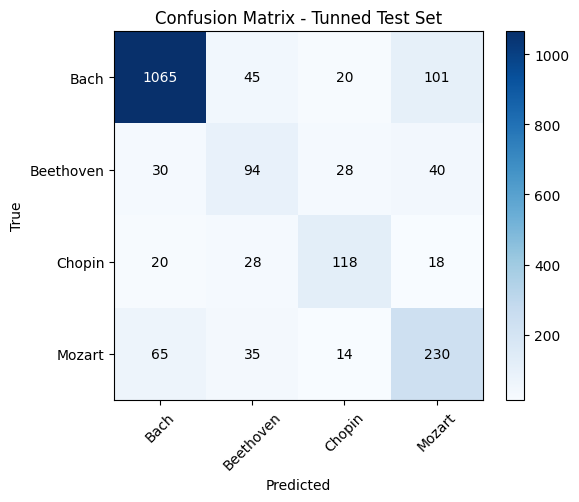

In [174]:
cm = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(6,5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(classes))); ax.set_xticklabels(classes, rotation=45)
ax.set_yticks(range(len(classes))); ax.set_yticklabels(classes)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix - Tunned Test Set')
for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                 color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im)
plt.tight_layout()
plt.show()

| Metric              | Before tuning | After tuning |      Change |
| ------------------- | ------------: | -----------: | ----------: |
| Correct predictions |         1,469 |        1,507 |         +38 |
| Test accuracy       |         75.3% |        77.2% | +1.9 points |
| Macro F1-score      |         63.3% |        65.9% | +2.6 points |
| Weighted F1-score   |         75.7% |        77.6% | +1.9 points |



- Bach: Correct predictions increased from 1,043 to 1,065. Its F1-score improved from 86.8% to 88.3%.
- Beethoven: Correct predictions increased from 88 to 94. Its F1-score improved - slightly from 46.3% to 47.7%, but it remains the weakest class.
- Chopin: Correct predictions increased from 103 to 118. Its F1-score improved considerably from 59.0% to 64.8%.
- Mozart: Correct predictions decreased slightly from 235 to 230, although its precision improved because fewer other samples were incorrectly classified as - Mozart. Its F1-score increased from 61.0% to 62.8%.

## 9. Conclusion



This project demonstrated that a hybrid CNN-LSTM (CRNN) architecture can identify the composer of a classical piano piece from a short, binarized MIDI piano-roll window with substantially better accuracy than chance or naive baselines. Using a rigorous, piece-level grouped data split to prevent leakage and class weighting to counter a heavily imbalanced corpus, the baseline model reached 75.3% test accuracy, and a Hyperband hyperparameter search improved this to 77.2% test accuracy with a corresponding rise in macro-average F1 from 0.633 to 0.659. The convolutional layers appear to capture the local harmonic and textural cues that most clearly separate Bach's dense, contrapuntal writing from the other three composers, reflected in Bach consistently obtaining the highest per-class F1-score of any composer (0.883 after tuning). The recurrent layers add temporal context across the window, but this alone was not sufficient to reliably separate Beethoven from Mozart, whose F1-scores of 0.477 and 0.628, respectively, remained the two weakest results even after tuning. Overall, the results confirm the viability of a hybrid CNN-LSTM approach for symbolic composer identification while highlighting that model capacity and hyperparameter tuning alone cannot fully resolve inherent stylistic overlap between historically adjacent composers; closing that remaining gap will likely require richer input representations — such as note-density, polyphony, or tempo features, or longer analysis windows — rather than further architectural tuning of the current pipeline.